# Lab 4: Bias–Variance ,Regularization and Logistic Regression



## 1. Bias, Variance, Underfitting, and Overfitting

- **Bias:** Error caused when the model is too simple.
- **Variance:** Error caused when the model changes too much with the training data.
- **Underfitting:** High bias and low variance.
- **Overfitting:** Low bias and high variance.
- **Good fit:** The point where bias and variance are balanced.

Saving lab.png to lab.png


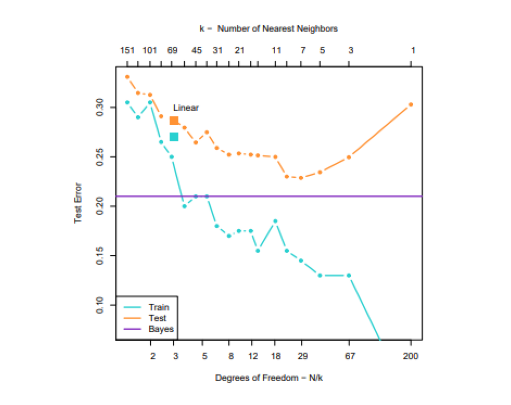

Image path: /content/lab.png


In [13]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Select the image from your computer
uploaded = files.upload()

# Uploaded image path inside Colab
image_name = next(iter(uploaded))
image_path = f"/content/{image_name}"

# Open and display
image = Image.open(image_path)

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image path:", image_path)

## 2. Bias–Variance Formula

The complete MSE decomposition is:

$$
\begin{aligned}
\operatorname{MSE}(x_0)
&= E_T\left[\left(f(x_0)-\hat{y}_0\right)^2\right] \\[4pt]
&= E_T\left[\left(\hat{y}_0-E_T(\hat{y}_0)\right)^2\right]
+\left[E_T(\hat{y}_0)-f(x_0)\right]^2 \\[4pt]
&= \operatorname{Var}_T(\hat{y}_0)
+\operatorname{Bias}^2(\hat{y}_0).
\end{aligned}
$$

Here:

- $E_T$ represents expectation over different training datasets.
- $\hat{y}_0$ is the model prediction at $x_0$.
- $f(x_0)$ is the true target function.
- The first component is variance.
- The second component is squared bias.

For linear regression:

$$
\hat{\beta}=(X^TX)^+X^Ty,
\qquad
H=X(X^TX)^+X^T
$$

The closed-form bias and variance calculations are:

$$
\operatorname{Bias}^2
=
\operatorname{mean}
\left[
\left(E(\hat y)-f(x)\right)^2
\right]
$$

$$
\operatorname{Variance}
=
\frac{\hat{\sigma}^2}{n}\operatorname{tr}(H)
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

# Load the standard dataset
data = load_diabetes(as_frame=True)
X = data.data.to_numpy()
y = data.target.to_numpy()
feature_names = np.array(data.feature_names)

print('Dataset shape:', X.shape)
print('Features:', feature_names)

Dataset shape: (442, 10)
Features: ['age' 'sex' 'bmi' 'bp' 's1' 's2' 's3' 's4' 's5' 's6']


## 3. Calculate Bias and Variance

The model remains linear. Complexity is increased only by adding the original dataset features one at a time. The complete linear model is used as the reference $f(x)$.

In [2]:
# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, train_size=70, random_state=42
)

# Standardize using training data
mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)
X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

def add_intercept(A):
    return np.column_stack((np.ones(len(A)), A))

# Full linear model gives the reference f(x)
X_full = add_intercept(X_train)
beta_full = np.linalg.pinv(X_full.T @ X_full) @ X_full.T @ y_train
f_reference = X_full @ beta_full

# Estimate noise variance
residual = y_train - f_reference
sigma2 = (residual @ residual) / (len(y_train) - X_full.shape[1])

bias2 = []
variance = []

for k in range(1, 11):
    Xk = add_intercept(X_train[:, :k])
    H = Xk @ np.linalg.pinv(Xk.T @ Xk) @ Xk.T

    expected_prediction = H @ f_reference
    bias2.append(np.mean((expected_prediction - f_reference) ** 2))
    variance.append(sigma2 * np.trace(H) / len(y_train))

results = pd.DataFrame({
    'Features': np.arange(1, 11),
    'Bias squared': bias2,
    'Variance': variance
})

print(results.round(2).to_string(index=False))

 Features  Bias squared  Variance
        1       1726.74     95.00
        2       1703.25    142.51
        3        583.73    190.01
        4         92.16    237.51
        5         52.37    285.01
        6         37.61    332.51
        7          2.41    380.02
        8          0.42    427.52
        9          0.18    475.02
       10          0.00    522.52


## 4. Bias–Variance Trade-off and Good Fit

The intersection of the bias² and variance curves gives the balanced model. Because the number of features must be an integer, the intersection is rounded to the nearest feature count.

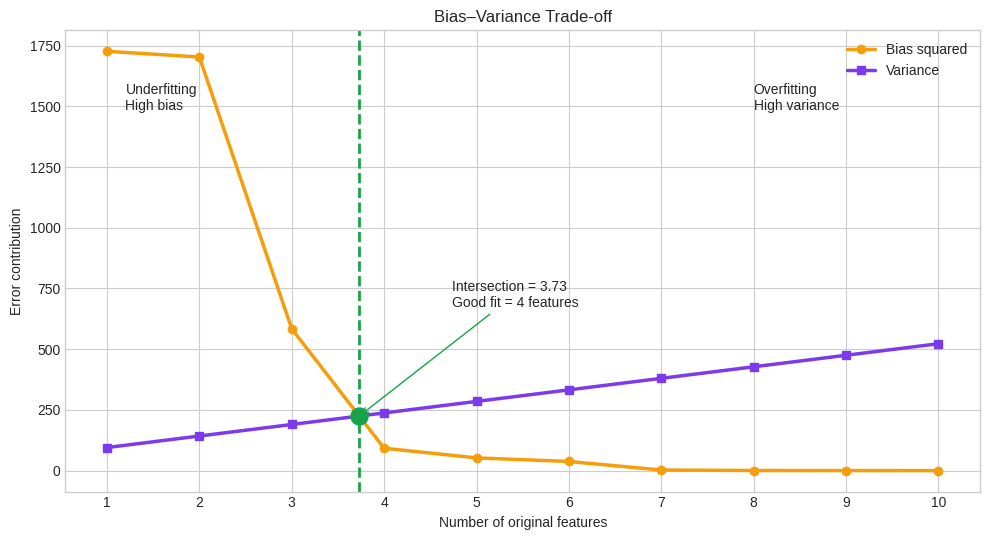

Good-fit model: 4 features
Selected features: age, sex, bmi, bp


In [3]:
k = results['Features'].to_numpy()
b = results['Bias squared'].to_numpy()
v = results['Variance'].to_numpy()
difference = b - v

# Find where the two lines cross
i = np.where(np.sign(difference[:-1]) != np.sign(difference[1:]))[0][0]
intersection_x = k[i] + (0 - difference[i]) / (difference[i + 1] - difference[i])
intersection_y = b[i] + (intersection_x - k[i]) * (b[i + 1] - b[i])
good_fit = int(np.round(intersection_x))

plt.figure(figsize=(10, 5.5))
plt.plot(k, b, 'o-', linewidth=2.5, label='Bias squared', color='#f59e0b')
plt.plot(k, v, 's-', linewidth=2.5, label='Variance', color='#7c3aed')

plt.scatter(intersection_x, intersection_y, s=150, color='#16a34a', zorder=5)
plt.axvline(intersection_x, linestyle='--', linewidth=2, color='#16a34a')
plt.annotate(
    f'Intersection = {intersection_x:.2f}\nGood fit = {good_fit} features',
    xy=(intersection_x, intersection_y),
    xytext=(intersection_x + 1, intersection_y + 450),
    arrowprops=dict(arrowstyle='->', color='#16a34a')
)

plt.text(1.2, max(b) * 0.86, 'Underfitting\nHigh bias')
plt.text(8.0, max(b) * 0.86, 'Overfitting\nHigh variance')
plt.xlabel('Number of original features')
plt.ylabel('Error contribution')
plt.title('Bias–Variance Trade-off')
plt.xticks(k)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Good-fit model: {good_fit} features')
print('Selected features:', ', '.join(feature_names[:good_fit]))

## 5. Ridge and Lasso Regularization

**Ridge (L2)** shrinks coefficients:

$$
J_{L2}=\operatorname{MSE}+\lambda\sum_{j=1}^{p}\beta_j^2
$$

**Lasso (L1)** can make coefficients exactly zero:

$$
J_{L1}=\operatorname{MSE}+\lambda\sum_{j=1}^{p}|\beta_j|
$$

### Closed-form equations used

$$
\hat\beta_{OLS}=(X^TX)^+X^Ty
$$

$$
\hat\beta_{Ridge}=(X^TX+\lambda I)^{-1}X^Ty
$$

General Lasso has no single matrix closed form. Its closed-form coordinate update is

$$
\beta_j\leftarrow\frac{S(\rho_j,\lambda)}{z_j},
\qquad
S(a,\lambda)=\operatorname{sign}(a)\max(|a|-\lambda,0)
$$

Saving 0_MuVvxE8pkBLtPzrx.png to 0_MuVvxE8pkBLtPzrx.png


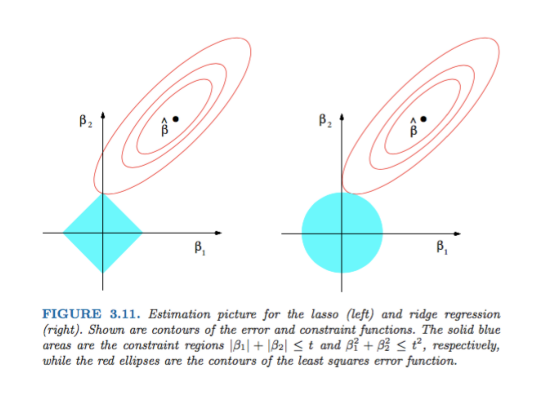

Image path: /content/0_MuVvxE8pkBLtPzrx.png


In [12]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Select the image from your computer
uploaded = files.upload()

# Uploaded image path inside Colab
image_name = next(iter(uploaded))
image_path = f"/content/{image_name}"

# Open and display
image = Image.open(image_path)

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image path:", image_path)

In [4]:
def soft_threshold(value, alpha):
    return np.sign(value) * max(abs(value) - alpha, 0)

def fit_models(Xtr, ytr, ridge_alpha=50, lasso_alpha=8):
    y_mean = ytr.mean()
    yc = ytr - y_mean

    # OLS closed form
    beta_ols = np.linalg.pinv(Xtr.T @ Xtr) @ Xtr.T @ yc

    # Ridge closed form
    I = np.eye(Xtr.shape[1])
    beta_ridge = np.linalg.pinv(Xtr.T @ Xtr + ridge_alpha * I) @ Xtr.T @ yc

    # Lasso closed-form coordinate updates
    beta_lasso = np.zeros(Xtr.shape[1])
    for _ in range(2000):
        old = beta_lasso.copy()
        for j in range(Xtr.shape[1]):
            r = yc - Xtr @ beta_lasso + Xtr[:, j] * beta_lasso[j]
            rho = Xtr[:, j] @ r / len(ytr)
            z = Xtr[:, j] @ Xtr[:, j] / len(ytr)
            beta_lasso[j] = soft_threshold(rho, lasso_alpha) / z
        if np.max(np.abs(beta_lasso - old)) < 1e-7:
            break

    return y_mean, {
        'Linear Regression': beta_ols,
        'Ridge': beta_ridge,
        'Lasso': beta_lasso
    }

def compare_models(Xtr, Xte, ytr, yte):
    intercept, models = fit_models(Xtr, ytr)
    rows = []

    for name, beta in models.items():
        train_pred = intercept + Xtr @ beta
        test_pred = intercept + Xte @ beta
        rows.append({
            'Model': name,
            'Train MSE': np.mean((ytr - train_pred) ** 2),
            'Test MSE': np.mean((yte - test_pred) ** 2),

        })

    return pd.DataFrame(rows)

original_comparison = compare_models(X_train, X_test, y_train, y_test)
print(original_comparison.round(2).to_string(index=False))

            Model  Train MSE  Test MSE
Linear Regression    2802.63   3729.66
            Ridge    2992.98   3907.52
            Lasso    2954.25   3969.59


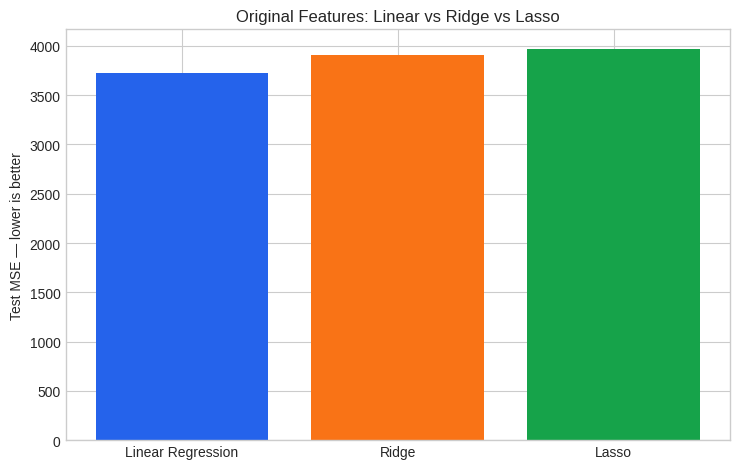

In [5]:
# Compare the three models on the original features
colors = ['#2563eb', '#f97316', '#16a34a']

plt.figure(figsize=(7.5, 4.8))
plt.bar(original_comparison['Model'], original_comparison['Test MSE'], color=colors)
plt.ylabel('Test MSE — lower is better')
plt.title('Original Features: Linear vs Ridge vs Lasso')
plt.tight_layout()
plt.show()

## 6. Comparison After Adding Irrelevant Features

One hundred random features are added. These features contain no useful target information.

In [6]:
rng = np.random.default_rng(7)

noise_train = rng.normal(size=(len(X_train), 100))
noise_test = rng.normal(size=(len(X_test), 100))

# Standardize noisy features
noise_mean = noise_train.mean(axis=0)
noise_std = noise_train.std(axis=0)
noise_train = (noise_train - noise_mean) / noise_std
noise_test = (noise_test - noise_mean) / noise_std

X_train_noisy = np.column_stack((X_train, noise_train))
X_test_noisy = np.column_stack((X_test, noise_test))

noisy_comparison = compare_models(
    X_train_noisy, X_test_noisy, y_train, y_test
)

print(noisy_comparison.round(2).to_string(index=False))

            Model  Train MSE  Test MSE
Linear Regression       0.00   9866.52
            Ridge     696.66   5364.75
            Lasso    1823.11   4742.58


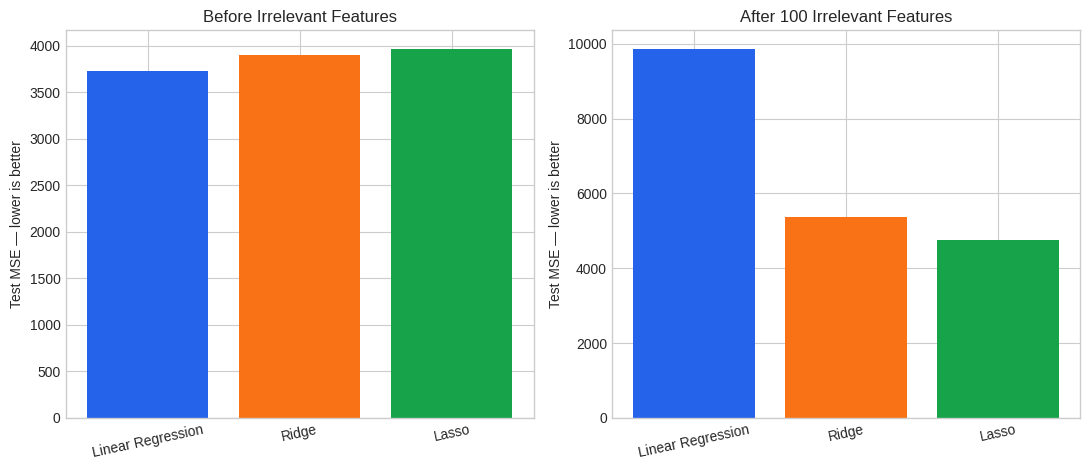

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Before adding irrelevant features
axes[0].bar(
    original_comparison['Model'],
    original_comparison['Test MSE'],
    color=colors
)

axes[0].set_title('Before Irrelevant Features')
axes[0].set_ylabel('Test MSE — lower is better')

# After adding irrelevant features
axes[1].bar(
    noisy_comparison['Model'],
    noisy_comparison['Test MSE'],
    color=colors
)

axes[1].set_title('After 100 Irrelevant Features')
axes[1].set_ylabel('Test MSE — lower is better')

for ax in axes:
    ax.tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.show()

## 7. Logistic Regression

Logistic Regression is used for **binary classification**, where the target is 0 or 1. It first calculates a linear value

$$
z=\beta_0+\beta_1x_1+\cdots+\beta_px_p
$$

and converts it into a probability using the **sigmoid function**:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If $\sigma(z)\geq0.5$, the predicted class is 1; otherwise it is 0.

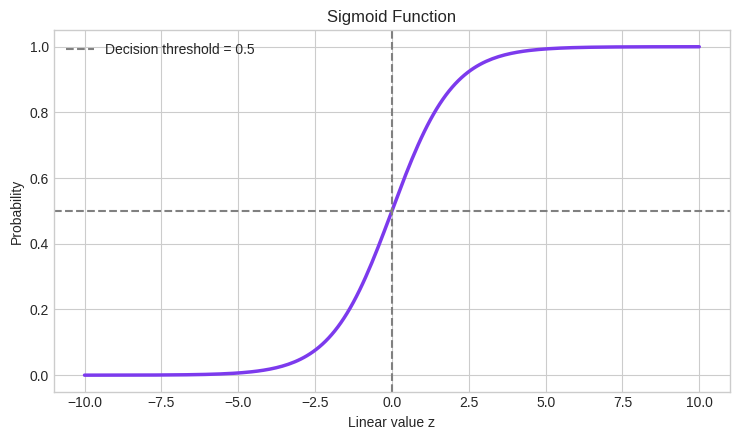

In [8]:
# Sigmoid function used by Logistic Regression
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(7.5, 4.5))
plt.plot(z, sigmoid(z), color='#7c3aed', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle='--', label='Decision threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Linear value z')
plt.ylabel('Probability')
plt.title('Sigmoid Function')
plt.legend()
plt.tight_layout()
plt.show()

### 7.1 Logistic Regression Using the Library

The standard Breast Cancer Wisconsin dataset is used because it has two target classes. The model is created using:

```python
LogisticRegression(max_iter=1000)
```

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load a standard binary-classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class,
    test_size=0.25,
    random_state=42,
    stratify=y_class
)

# Standardize the features
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

# Apply Logistic Regression using sklearn
library_model = LogisticRegression(max_iter=1000, random_state=42)
library_model.fit(Xc_train_scaled, yc_train)

library_prediction = library_model.predict(Xc_test_scaled)
library_accuracy = accuracy_score(yc_test, library_prediction)
library_cm = confusion_matrix(yc_test, library_prediction)

print(f'Library Logistic Regression accuracy: {library_accuracy:.4f}')



Library Logistic Regression accuracy: 0.9860


### 7.2 Logistic Regression Without the Model Library

The same model is implemented using the sigmoid function and gradient descent:

$$
\beta\leftarrow\beta-\alpha\frac{X^T(\hat y-y)}{n}
$$

               Method  Accuracy
        Using sklearn     0.986
Without model library     0.979


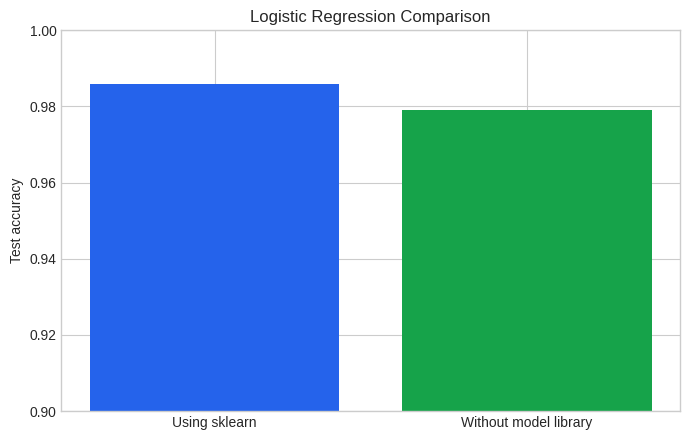

In [10]:
# Start with zero weights
weights = np.zeros(Xc_train_scaled.shape[1])
bias = 0.0
learning_rate = 0.1

# Gradient descent
for epoch in range(3000):
    probability = sigmoid(Xc_train_scaled @ weights + bias)

    weight_gradient = Xc_train_scaled.T @ (probability - yc_train) / len(yc_train)
    bias_gradient = np.mean(probability - yc_train)

    weights -= learning_rate * weight_gradient
    bias -= learning_rate * bias_gradient

# Prediction using threshold 0.5
scratch_probability = sigmoid(Xc_test_scaled @ weights + bias)
scratch_prediction = (scratch_probability >= 0.5).astype(int)
scratch_accuracy = accuracy_score(yc_test, scratch_prediction)

comparison_logistic = pd.DataFrame({
    'Method': ['Using sklearn', 'Without model library'],
    'Accuracy': [library_accuracy, scratch_accuracy]
})

print(comparison_logistic.round(4).to_string(index=False))

plt.figure(figsize=(7, 4.5))
plt.bar(comparison_logistic['Method'], comparison_logistic['Accuracy'],
        color=['#2563eb', '#16a34a'])
plt.ylim(0.90, 1.00)
plt.ylabel('Test accuracy')
plt.title('Logistic Regression Comparison')
plt.tight_layout()
plt.show()